
================ MÉTRICAS =================

Tiempo_Congestion_Horas: 1.0
Velocidad_Promedio: 67.77
Indice_Congestion: 32.23
Velocidad_Fluido: 79.49
Velocidad_Moderado: 50.8
Velocidad_Congestionado: 27.61

================ PREDICCIÓN FUTURA =================

En +1 horas se espera: Fluido
En +2 horas se espera: Fluido
En +3 horas se espera: Fluido
En +4 horas se espera: Fluido
En +5 horas se espera: Fluido
En +6 horas se espera: Moderado

================ PATRONES DE CONGESTIÓN =================

Horas con mayor probabilidad de congestión:
- 2:00 con 1 ocurrencias
- 11:00 con 1 ocurrencias

Conclusión: La hora más probable de congestión es alrededor de las 2:00.

================ RUTAS ALTERNATIVAS =================

Sugerencias durante congestión:
- Usar vías secundarias o rutas alternas
- Optar por transporte público o bicicleta
- Ajustar horarios de viaje para evitar horas pico

================ IMPACTO AMBIENTAL =================

Emisiones totales estimadas: 9400 g CO2
Emisiones 

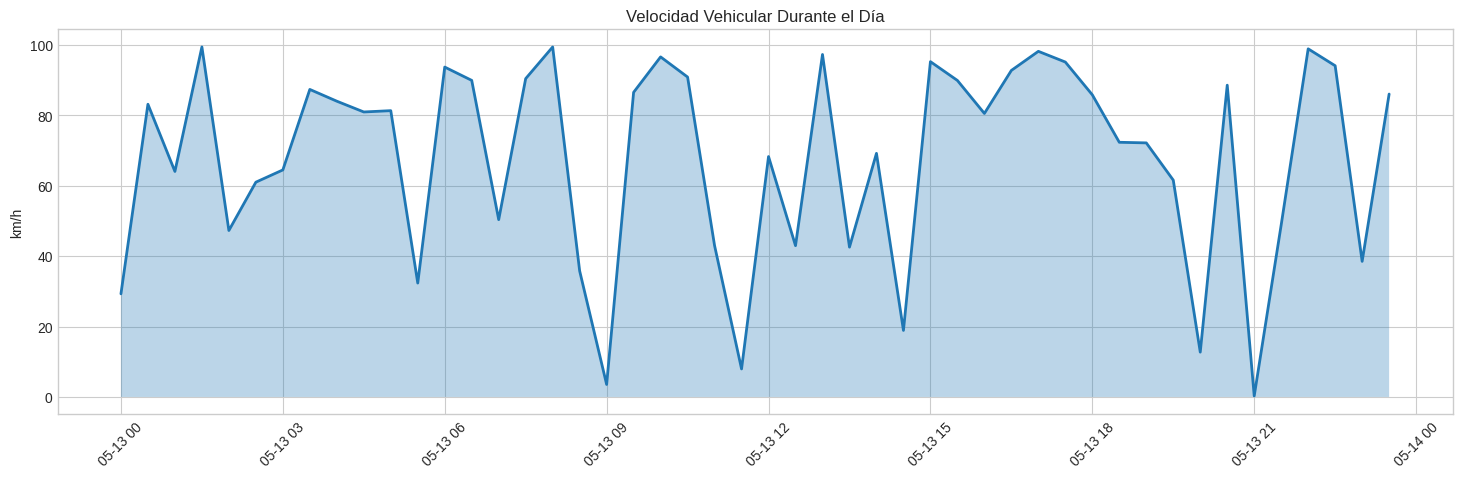

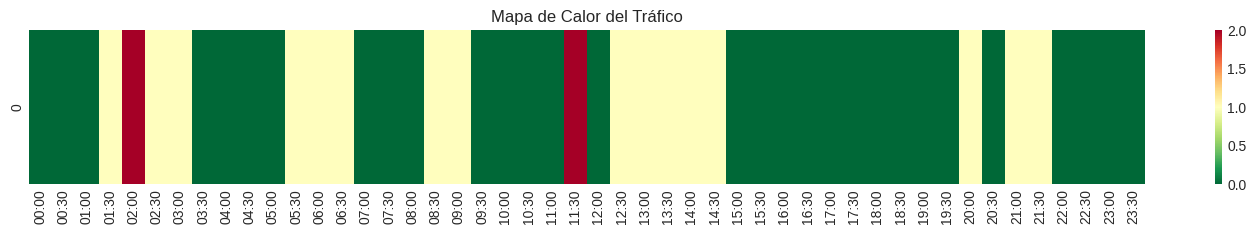


================ SEMÁFORO =================

00:00 🟢 Fluido
00:30 🟢 Fluido
01:00 🟢 Fluido
01:30 🟡 Moderado
02:00 🔴 Congestionado
02:30 🟡 Moderado
03:00 🟡 Moderado
03:30 🟢 Fluido
04:00 🟢 Fluido
04:30 🟢 Fluido
05:00 🟢 Fluido
05:30 🟡 Moderado
06:00 🟡 Moderado
06:30 🟡 Moderado
07:00 🟢 Fluido
07:30 🟢 Fluido
08:00 🟢 Fluido
08:30 🟡 Moderado
09:00 🟡 Moderado
09:30 🟢 Fluido
10:00 🟢 Fluido
10:30 🟢 Fluido
11:00 🟢 Fluido
11:30 🔴 Congestionado
12:00 🟢 Fluido
12:30 🟡 Moderado
13:00 🟡 Moderado
13:30 🟡 Moderado
14:00 🟡 Moderado
14:30 🟡 Moderado
15:00 🟢 Fluido
15:30 🟢 Fluido
16:00 🟢 Fluido
16:30 🟢 Fluido
17:00 🟢 Fluido
17:30 🟢 Fluido
18:00 🟢 Fluido
18:30 🟢 Fluido
19:00 🟢 Fluido
19:30 🟢 Fluido
20:00 🟡 Moderado
20:30 🟢 Fluido
21:00 🟡 Moderado
21:30 🟡 Moderado
22:00 🟢 Fluido
22:30 🟢 Fluido
23:00 🟢 Fluido
23:30 🟢 Fluido


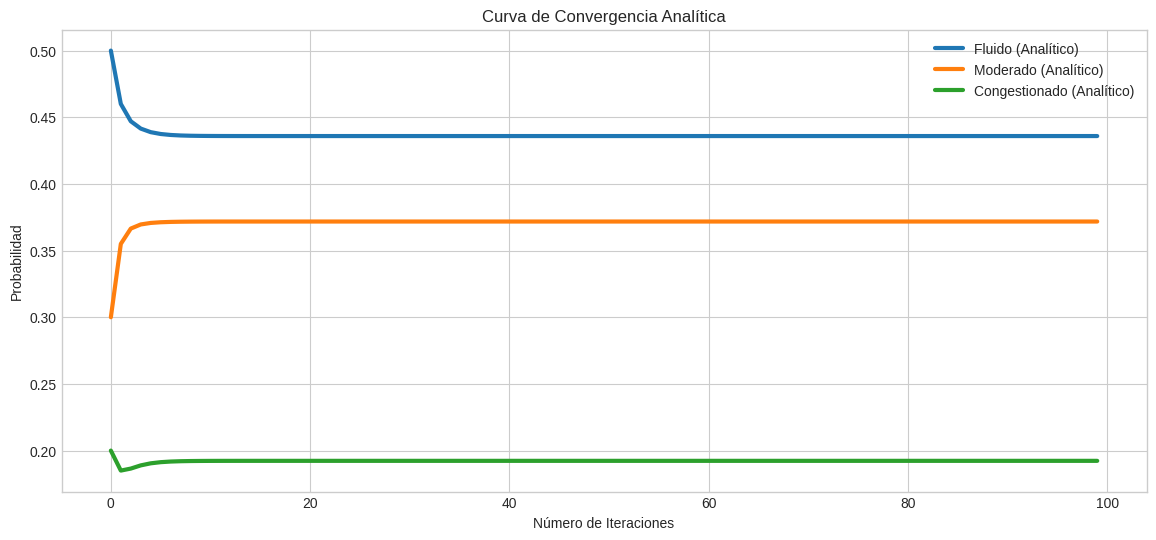


================ DISTRIBUCIÓN ESTACIONARIA =================

Fluido: 0.4359
Moderado: 0.3718
Congestionado: 0.1923


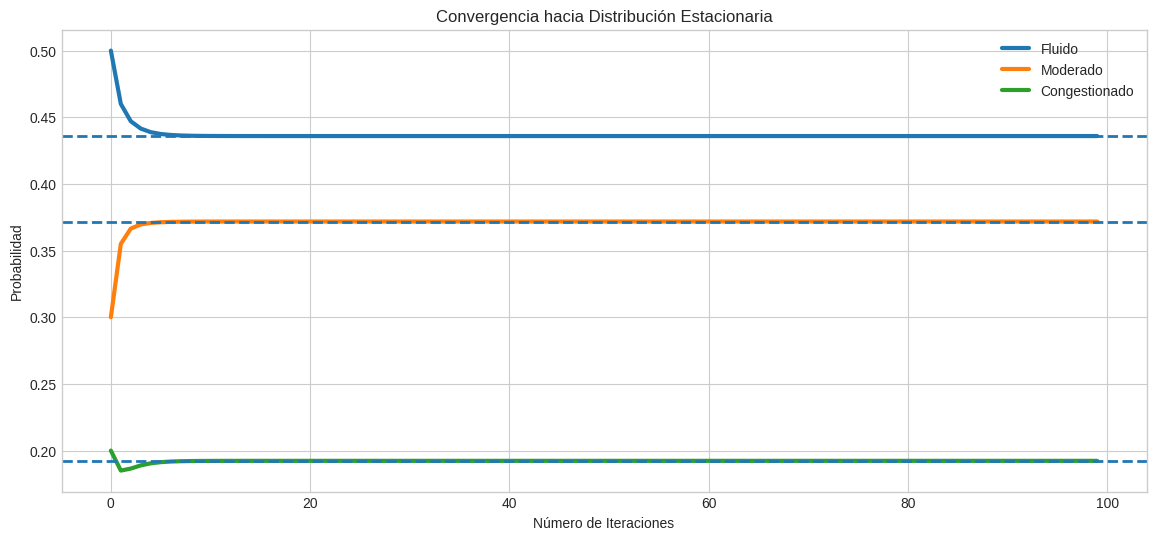

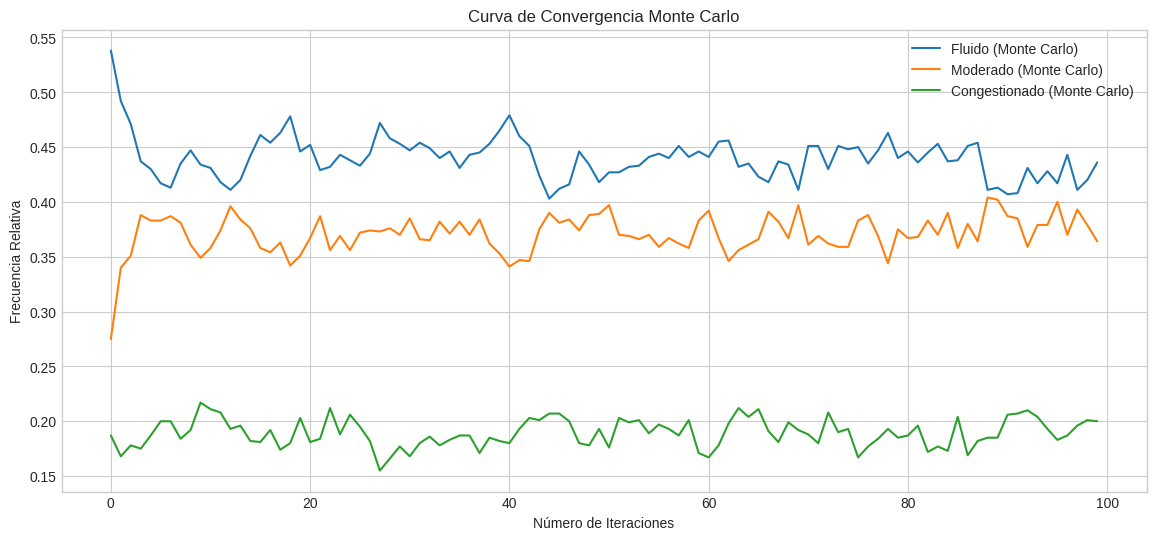

In [8]:
# ============================================================
# PREDICCIÓN DE TRÁFICO VEHICULAR
# MODELO OCULTO DE MARKOV (HMM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.animation import FuncAnimation

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ============================================================
# CLASE HMM
# ============================================================

class TrafficHMM:
    def __init__(self):
        self.states = ['Fluido','Moderado','Congestionado']
        self.observations = ['Alta','Media','Baja']
        self.initial_distribution = np.array([0.5,0.3,0.2])
        self.transition_matrix = np.array([
            [0.70,0.25,0.05],
            [0.30,0.50,0.20],
            [0.10,0.40,0.50]
        ])
        self.emission_matrix = np.array([
            [0.80,0.15,0.05],
            [0.20,0.60,0.20],
            [0.05,0.25,0.70]
        ])
        self.semaphore_map = {'Fluido':'🟢','Moderado':'🟡','Congestionado':'🔴'}

    def simulate(self,n_steps=48):
        current_state_idx=np.random.choice(len(self.states),p=self.initial_distribution)
        state_history,obs_history,speed_history=[],[],[]
        start_time=datetime(2026,5,13,0,0)
        for step in range(n_steps):
            current_state=self.states[current_state_idx]
            state_history.append(current_state)
            obs_idx=np.random.choice(len(self.observations),p=self.emission_matrix[current_state_idx])
            obs_label=self.observations[obs_idx]
            obs_history.append(obs_label)
            if obs_label=='Alta': speed=np.random.uniform(80,100)
            elif obs_label=='Media': speed=np.random.uniform(40,80)
            else: speed=np.random.uniform(0,40)
            speed_history.append(round(speed,2))
            current_state_idx=np.random.choice(len(self.states),p=self.transition_matrix[current_state_idx])
        return state_history,obs_history,speed_history

    def predict_future(self,current_state,future_steps=6):
        predictions=[]
        state_idx=self.states.index(current_state)
        for _ in range(future_steps):
            next_state_idx=np.random.choice(len(self.states),p=self.transition_matrix[state_idx])
            predictions.append(self.states[next_state_idx])
            state_idx=next_state_idx
        return predictions

# ============================================================
# CREAR MODELO Y SIMULAR
# ============================================================

hmm=TrafficHMM()
states_real,observations,speeds=hmm.simulate(48)

time_index=[datetime(2026,5,13,0,0)+timedelta(minutes=30*i) for i in range(48)]
df=pd.DataFrame({'Hora':time_index,'Estado_Real':states_real,'Observacion':observations,'Velocidad_kmh':speeds})
df['Semaforo']=df['Estado_Real'].map(hmm.semaphore_map)

# ============================================================
# MÉTRICAS
# ============================================================

def calculate_metrics(dataframe):
    congestion_periods=len(dataframe[dataframe['Estado_Real']=='Congestionado'])
    congestion_hours=congestion_periods*0.5
    avg_speed=dataframe['Velocidad_kmh'].mean()
    congestion_index=(100-avg_speed)
    avg_speed_state=dataframe.groupby('Estado_Real')['Velocidad_kmh'].mean()
    return {'Tiempo_Congestion_Horas':round(congestion_hours,2),
            'Velocidad_Promedio':round(avg_speed,2),
            'Indice_Congestion':round(congestion_index,2),
            'Velocidad_Fluido':round(avg_speed_state.get('Fluido',0),2),
            'Velocidad_Moderado':round(avg_speed_state.get('Moderado',0),2),
            'Velocidad_Congestionado':round(avg_speed_state.get('Congestionado',0),2)}

metrics=calculate_metrics(df)
print("\n================ MÉTRICAS =================\n")
for k,v in metrics.items(): print(f"{k}: {v}")

# ============================================================
# 6. PREDICCIÓN FUTURA
# ============================================================

print("\n================ PREDICCIÓN FUTURA =================\n")
future_prediction=hmm.predict_future(states_real[-1],6)
for idx,pred in enumerate(future_prediction):
    print(f"En +{idx+1} horas se espera: {pred}")

  # ============================================================
# 7. PATRONES DE CONGESTIÓN
# ============================================================

print("\n================ PATRONES DE CONGESTIÓN =================\n")

# Filtrar las horas donde hubo congestión
congestion_hours = df[df['Estado_Real'] == 'Congestionado']['Hora'].dt.hour

if len(congestion_hours) > 0:
    # Contar frecuencia de congestión por hora
    freq = congestion_hours.value_counts().sort_index()

    # Mostrar las horas con mayor frecuencia
    top_hours = freq.head(5)  # las 5 horas más frecuentes
    print("Horas con mayor probabilidad de congestión:")
    for h, count in top_hours.items():
        print(f"- {h}:00 con {count} ocurrencias")

    # Detectar patrones de mañana y tarde
    morning_peak = congestion_hours[(congestion_hours >= 6) & (congestion_hours <= 9)]
    evening_peak = congestion_hours[(congestion_hours >= 17) & (congestion_hours <= 20)]

    if len(morning_peak) > 0:
        print("Patrón: Congestión frecuente en la mañana (6:00–9:00)")
    if len(evening_peak) > 0:
        print("Patrón: Congestión frecuente en la tarde (17:00–20:00)")

    # Conclusión general
    most_common_hour = freq.idxmax()
    print(f"\nConclusión: La hora más probable de congestión es alrededor de las {most_common_hour}:00.")
else:
    print("El tráfico se mantuvo fluido todo el día, sin patrones de congestión.")

# ============================================================
# 8. RUTAS ALTERNATIVAS
# ============================================================

print("\n================ RUTAS ALTERNATIVAS =================\n")
if len(congestion_hours)>0:
    print("Sugerencias durante congestión:")
    print("- Usar vías secundarias o rutas alternas")
    print("- Optar por transporte público o bicicleta")
    print("- Ajustar horarios de viaje para evitar horas pico")
else:
    print("El tráfico se mantuvo fluido, no se requieren rutas alternas.")

# ============================================================
# 9. IMPACTO AMBIENTAL
# ============================================================

print("\n================ IMPACTO AMBIENTAL =================\n")
emission_map={'Fluido':150,'Moderado':250,'Congestionado':450}
df['Emisiones_CO2']=df['Estado_Real'].map(emission_map)
total_emissions=df['Emisiones_CO2'].sum()
congestion_emissions=df[df['Estado_Real']=='Congestionado']['Emisiones_CO2'].sum()
print(f"Emisiones totales estimadas: {round(total_emissions,2)} g CO2")
print(f"Emisiones en congestión: {round(congestion_emissions,2)} g CO2")
print("Conclusión: La congestión incrementa significativamente las emisiones, afectando la calidad del aire urbano.")

# ============================================================
# VISUALIZACIONES
# ============================================================

plt.figure(figsize=(18,5))
plt.plot(df['Hora'],df['Velocidad_kmh'],linewidth=2)
plt.fill_between(df['Hora'],df['Velocidad_kmh'],alpha=0.3)
plt.title('Velocidad Vehicular Durante el Día')
plt.ylabel('km/h'); plt.xticks(rotation=45); plt.show()

state_numeric=df['Estado_Real'].map({'Fluido':0,'Moderado':1,'Congestionado':2}).values.reshape(1,48)
plt.figure(figsize=(18,2))
sns.heatmap(state_numeric,cmap='RdYlGn_r',cbar=True,
            xticklabels=[h.strftime("%H:%M") for h in df['Hora']])
plt.title('Mapa de Calor del Tráfico'); plt.xticks(rotation=90); plt.show()

print("\n================ SEMÁFORO =================\n")
for idx,row in df.iterrows():
    print(f"{row['Hora'].strftime('%H:%M')} {row['Semaforo']} {row['Estado_Real']}")

# ============================================================
# CURVA DE CONVERGENCIA ANALÍTICA
# ============================================================

state_probabilities=[]
current_distribution=hmm.initial_distribution.copy()
state_probabilities.append(current_distribution)
for t in range(1,100):
    current_distribution=np.dot(current_distribution,hmm.transition_matrix)
    state_probabilities.append(current_distribution)
state_probabilities=np.array(state_probabilities)

plt.figure(figsize=(14,6))
plt.plot(state_probabilities[:,0],label='Fluido (Analítico)',linewidth=3)
plt.plot(state_probabilities[:,1],label='Moderado (Analítico)',linewidth=3)
plt.plot(state_probabilities[:,2],label='Congestionado (Analítico)',linewidth=3)
plt.title('Curva de Convergencia Analítica')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Probabilidad')
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# DISTRIBUCIÓN ESTACIONARIA
# ============================================================

print("\n================ DISTRIBUCIÓN ESTACIONARIA =================\n")
eigvals, eigvecs = np.linalg.eig(hmm.transition_matrix.T)
stationary = np.real(eigvecs[:, np.isclose(eigvals, 1)])
stationary = stationary[:, 0]
stationary = stationary / stationary.sum()   # CORREGIDO

for i, state in enumerate(hmm.states):
    print(f"{state}: {stationary[i]:.4f}")

# ============================================================
# CONVERGENCIA HACIA DISTRIBUCIÓN
# ============================================================

plt.figure(figsize=(14,6))
plt.plot(state_probabilities[:,0],label='Fluido',linewidth=3)
plt.plot(state_probabilities[:,1],label='Moderado',linewidth=3)
plt.plot(state_probabilities[:,2],label='Congestionado',linewidth=3)
plt.axhline(y=stationary[0],linestyle='--',linewidth=2)
plt.axhline(y=stationary[1],linestyle='--',linewidth=2)
plt.axhline(y=stationary[2],linestyle='--',linewidth=2)
plt.title('Convergencia hacia Distribución Estacionaria')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Probabilidad')
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# CURVA DE CONVERGENCIA MONTECARLO
# ============================================================

n_simulations = 1000
n_steps = 100
counts = np.zeros((n_steps, len(hmm.states)))

for sim in range(n_simulations):
    state_idx = np.random.choice(len(hmm.states), p=hmm.initial_distribution)
    for t in range(n_steps):
        counts[t, state_idx] += 1
        state_idx = np.random.choice(len(hmm.states), p=hmm.transition_matrix[state_idx])

freqs = counts / n_simulations

plt.figure(figsize=(14,6))
plt.plot(freqs[:,0], label='Fluido (Monte Carlo)')
plt.plot(freqs[:,1], label='Moderado (Monte Carlo)')
plt.plot(freqs[:,2], label='Congestionado (Monte Carlo)')
plt.title('Curva de Convergencia Monte Carlo')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Frecuencia Relativa')
plt.legend(); plt.grid(True); plt.show()


================ MÉTRICAS =================

Tiempo_Congestion_Horas: 0.5
Velocidad_Promedio: 76.76
Indice_Congestion: 23.24
Velocidad_Fluido: 78.65
Velocidad_Moderado: 71.97
Velocidad_Congestionado: 7.95

================ PREDICCIÓN FUTURA =================

En +1 horas se espera: Fluido
En +2 horas se espera: Fluido
En +3 horas se espera: Fluido
En +4 horas se espera: Fluido
En +5 horas se espera: Fluido
En +6 horas se espera: Moderado

================ PATRONES DE CONGESTIÓN =================


================ RUTAS ALTERNATIVAS =================

Sugerencias durante congestión:
- Usar vías secundarias o rutas alternas
- Optar por transporte público o bicicleta
- Ajustar horarios de viaje para evitar horas pico

================ IMPACTO AMBIENTAL =================

Emisiones totales estimadas: 7800 g CO2
Emisiones en congestión: 450 g CO2
Conclusión: La congestión incrementa significativamente las emisiones, afectando la calidad del aire urbano.


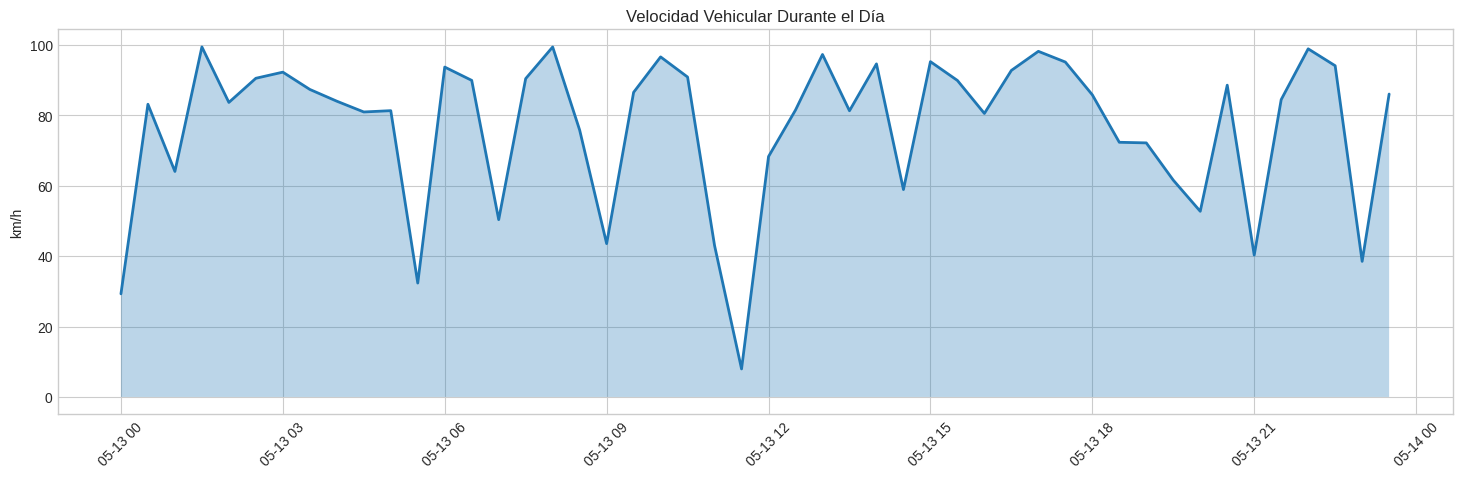

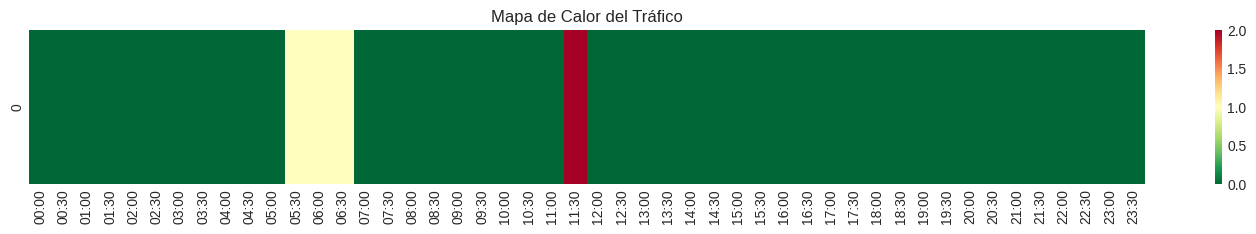


================ SEMÁFORO =================

00:00 🟢 Fluido
00:30 🟢 Fluido
01:00 🟢 Fluido
01:30 🟢 Fluido
02:00 🟢 Fluido
02:30 🟢 Fluido
03:00 🟢 Fluido
03:30 🟢 Fluido
04:00 🟢 Fluido
04:30 🟢 Fluido
05:00 🟢 Fluido
05:30 🟡 Moderado
06:00 🟡 Moderado
06:30 🟡 Moderado
07:00 🟢 Fluido
07:30 🟢 Fluido
08:00 🟢 Fluido
08:30 🟢 Fluido
09:00 🟢 Fluido
09:30 🟢 Fluido
10:00 🟢 Fluido
10:30 🟢 Fluido
11:00 🟢 Fluido
11:30 🔴 Congestionado
12:00 🟢 Fluido
12:30 🟢 Fluido
13:00 🟢 Fluido
13:30 🟢 Fluido
14:00 🟢 Fluido
14:30 🟢 Fluido
15:00 🟢 Fluido
15:30 🟢 Fluido
16:00 🟢 Fluido
16:30 🟢 Fluido
17:00 🟢 Fluido
17:30 🟢 Fluido
18:00 🟢 Fluido
18:30 🟢 Fluido
19:00 🟢 Fluido
19:30 🟢 Fluido
20:00 🟢 Fluido
20:30 🟢 Fluido
21:00 🟢 Fluido
21:30 🟢 Fluido
22:00 🟢 Fluido
22:30 🟢 Fluido
23:00 🟢 Fluido
23:30 🟢 Fluido


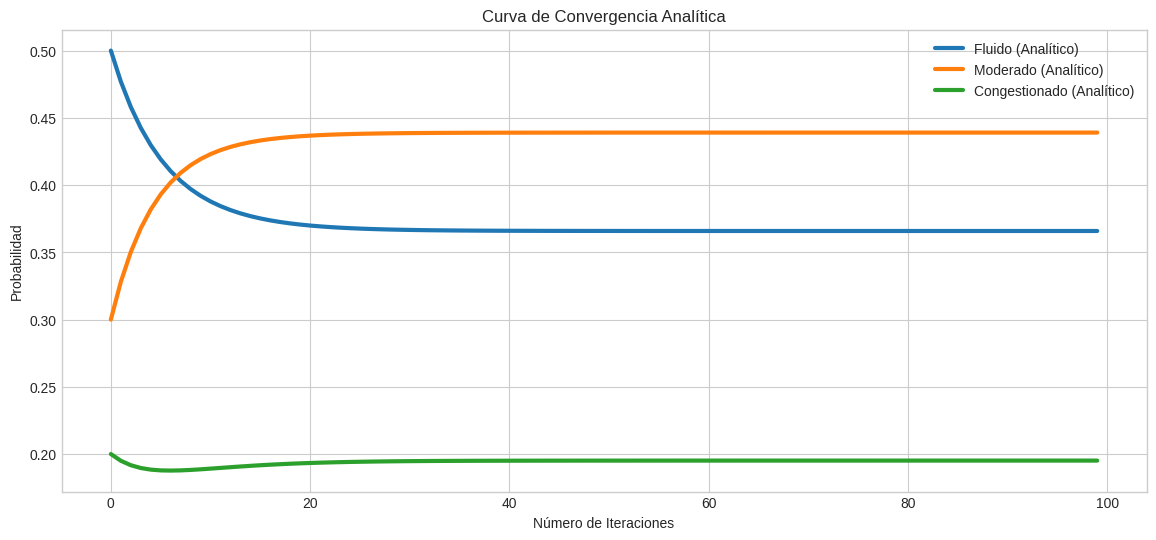


================ DISTRIBUCIÓN ESTACIONARIA =================

Fluido: 0.3659
Moderado: 0.4390
Congestionado: 0.1951


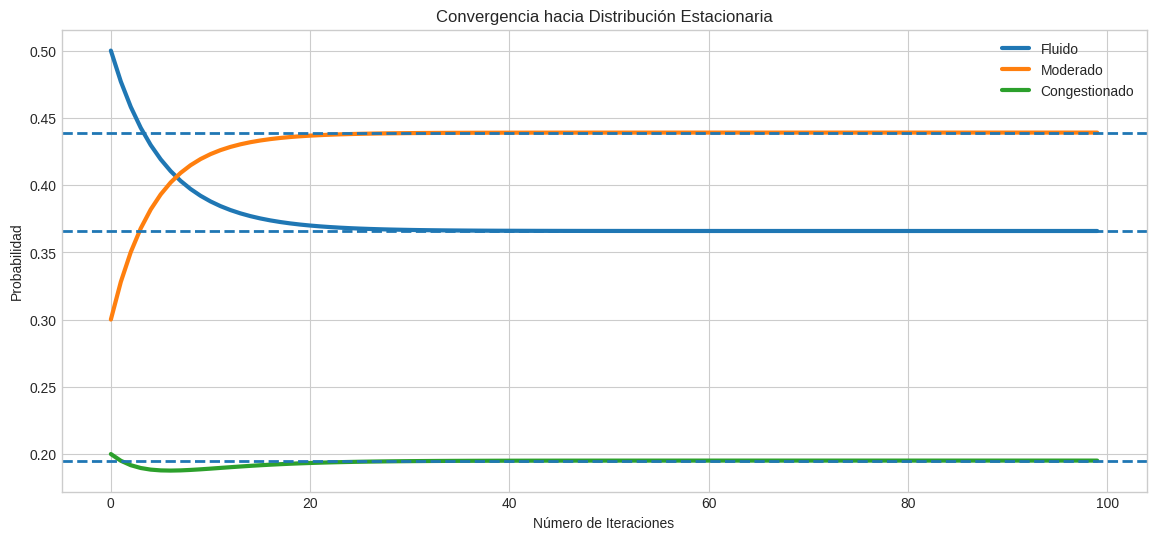

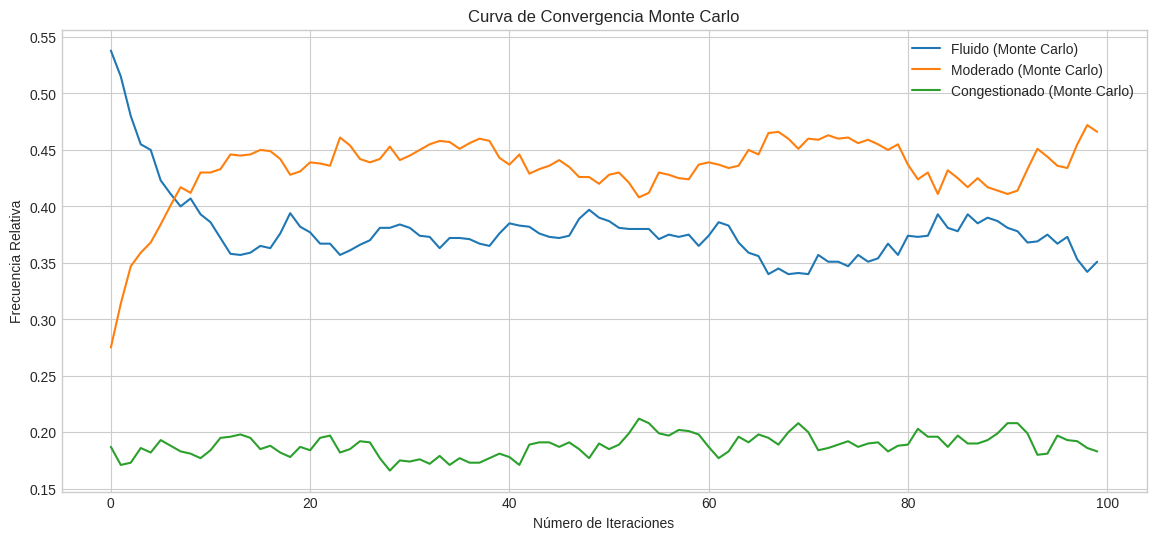

In [9]:
# ============================================================
# PREDICCIÓN DE TRÁFICO VEHICULAR
# MODELO OCULTO DE MARKOV (HMM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.animation import FuncAnimation

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ============================================================
# CLASE HMM
# ============================================================

class TrafficHMM:
    def __init__(self):
        self.states = ['Fluido','Moderado','Congestionado']
        self.observations = ['Alta','Media','Baja']
        self.initial_distribution = np.array([0.5,0.3,0.2])
        self.transition_matrix = np.array([

          [0.90, 0.08, 0.02],

          [0.07, 0.88, 0.05],

          [0.03, 0.12, 0.85]

          ] )
        self.emission_matrix = np.array([
            [0.80,0.15,0.05],
            [0.20,0.60,0.20],
            [0.05,0.25,0.70]
        ])
        self.semaphore_map = {'Fluido':'🟢','Moderado':'🟡','Congestionado':'🔴'}

    def simulate(self,n_steps=48):
        current_state_idx=np.random.choice(len(self.states),p=self.initial_distribution)
        state_history,obs_history,speed_history=[],[],[]
        start_time=datetime(2026,5,13,0,0)
        for step in range(n_steps):
            current_state=self.states[current_state_idx]
            state_history.append(current_state)
            obs_idx=np.random.choice(len(self.observations),p=self.emission_matrix[current_state_idx])
            obs_label=self.observations[obs_idx]
            obs_history.append(obs_label)
            if obs_label=='Alta': speed=np.random.uniform(80,100)
            elif obs_label=='Media': speed=np.random.uniform(40,80)
            else: speed=np.random.uniform(0,40)
            speed_history.append(round(speed,2))
            current_state_idx=np.random.choice(len(self.states),p=self.transition_matrix[current_state_idx])
        return state_history,obs_history,speed_history

    def predict_future(self,current_state,future_steps=6):
        predictions=[]
        state_idx=self.states.index(current_state)
        for _ in range(future_steps):
            next_state_idx=np.random.choice(len(self.states),p=self.transition_matrix[state_idx])
            predictions.append(self.states[next_state_idx])
            state_idx=next_state_idx
        return predictions

# ============================================================
# CREAR MODELO Y SIMULAR
# ============================================================

hmm=TrafficHMM()
states_real,observations,speeds=hmm.simulate(48)

time_index=[datetime(2026,5,13,0,0)+timedelta(minutes=30*i) for i in range(48)]
df=pd.DataFrame({'Hora':time_index,'Estado_Real':states_real,'Observacion':observations,'Velocidad_kmh':speeds})
df['Semaforo']=df['Estado_Real'].map(hmm.semaphore_map)

# ============================================================
# MÉTRICAS
# ============================================================

def calculate_metrics(dataframe):
    congestion_periods=len(dataframe[dataframe['Estado_Real']=='Congestionado'])
    congestion_hours=congestion_periods*0.5
    avg_speed=dataframe['Velocidad_kmh'].mean()
    congestion_index=(100-avg_speed)
    avg_speed_state=dataframe.groupby('Estado_Real')['Velocidad_kmh'].mean()
    return {'Tiempo_Congestion_Horas':round(congestion_hours,2),
            'Velocidad_Promedio':round(avg_speed,2),
            'Indice_Congestion':round(congestion_index,2),
            'Velocidad_Fluido':round(avg_speed_state.get('Fluido',0),2),
            'Velocidad_Moderado':round(avg_speed_state.get('Moderado',0),2),
            'Velocidad_Congestionado':round(avg_speed_state.get('Congestionado',0),2)}

metrics=calculate_metrics(df)
print("\n================ MÉTRICAS =================\n")
for k,v in metrics.items(): print(f"{k}: {v}")

# ============================================================
# 6. PREDICCIÓN FUTURA
# ============================================================

print("\n================ PREDICCIÓN FUTURA =================\n")
future_prediction=hmm.predict_future(states_real[-1],6)
for idx,pred in enumerate(future_prediction):
    print(f"En +{idx+1} horas se espera: {pred}")

# ============================================================
# 7. PATRONES DE CONGESTIÓN
# ============================================================

print("\n================ PATRONES DE CONGESTIÓN =================\n")
congestion_hours=df[df['Estado_Real']=='Congestionado']['Hora'].dt.hour
morning_peak=congestion_hours[(congestion_hours>=6)&(congestion_hours<=9)]
evening_peak=congestion_hours[(congestion_hours>=17)&(congestion_hours<=20)]
if len(morning_peak)>0: print("Patrón: Congestión frecuente en la mañana (6:00–9:00)")
if len(evening_peak)>0: print("Patrón: Congestión frecuente en la tarde (17:00–20:00)")
if len(congestion_hours)==0: print("No se detectaron patrones claros de congestión.")

# ============================================================
# 8. RUTAS ALTERNATIVAS
# ============================================================

print("\n================ RUTAS ALTERNATIVAS =================\n")
if len(congestion_hours)>0:
    print("Sugerencias durante congestión:")
    print("- Usar vías secundarias o rutas alternas")
    print("- Optar por transporte público o bicicleta")
    print("- Ajustar horarios de viaje para evitar horas pico")
else:
    print("El tráfico se mantuvo fluido, no se requieren rutas alternas.")

# ============================================================
# 9. IMPACTO AMBIENTAL
# ============================================================

print("\n================ IMPACTO AMBIENTAL =================\n")
emission_map={'Fluido':150,'Moderado':250,'Congestionado':450}
df['Emisiones_CO2']=df['Estado_Real'].map(emission_map)
total_emissions=df['Emisiones_CO2'].sum()
congestion_emissions=df[df['Estado_Real']=='Congestionado']['Emisiones_CO2'].sum()
print(f"Emisiones totales estimadas: {round(total_emissions,2)} g CO2")
print(f"Emisiones en congestión: {round(congestion_emissions,2)} g CO2")
print("Conclusión: La congestión incrementa significativamente las emisiones, afectando la calidad del aire urbano.")

# ============================================================
# VISUALIZACIONES
# ============================================================

plt.figure(figsize=(18,5))
plt.plot(df['Hora'],df['Velocidad_kmh'],linewidth=2)
plt.fill_between(df['Hora'],df['Velocidad_kmh'],alpha=0.3)
plt.title('Velocidad Vehicular Durante el Día')
plt.ylabel('km/h'); plt.xticks(rotation=45); plt.show()

state_numeric=df['Estado_Real'].map({'Fluido':0,'Moderado':1,'Congestionado':2}).values.reshape(1,48)
plt.figure(figsize=(18,2))
sns.heatmap(state_numeric,cmap='RdYlGn_r',cbar=True,
            xticklabels=[h.strftime("%H:%M") for h in df['Hora']])
plt.title('Mapa de Calor del Tráfico'); plt.xticks(rotation=90); plt.show()

print("\n================ SEMÁFORO =================\n")
for idx,row in df.iterrows():
    print(f"{row['Hora'].strftime('%H:%M')} {row['Semaforo']} {row['Estado_Real']}")

# ============================================================
# CURVA DE CONVERGENCIA ANALÍTICA
# ============================================================

state_probabilities=[]
current_distribution=hmm.initial_distribution.copy()
state_probabilities.append(current_distribution)
for t in range(1,100):
    current_distribution=np.dot(current_distribution,hmm.transition_matrix)
    state_probabilities.append(current_distribution)
state_probabilities=np.array(state_probabilities)

plt.figure(figsize=(14,6))
plt.plot(state_probabilities[:,0],label='Fluido (Analítico)',linewidth=3)
plt.plot(state_probabilities[:,1],label='Moderado (Analítico)',linewidth=3)
plt.plot(state_probabilities[:,2],label='Congestionado (Analítico)',linewidth=3)
plt.title('Curva de Convergencia Analítica')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Probabilidad')
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# DISTRIBUCIÓN ESTACIONARIA
# ============================================================

print("\n================ DISTRIBUCIÓN ESTACIONARIA =================\n")
eigvals, eigvecs = np.linalg.eig(hmm.transition_matrix.T)
stationary = np.real(eigvecs[:, np.isclose(eigvals, 1)])
stationary = stationary[:, 0]
stationary = stationary / stationary.sum()   # CORREGIDO

for i, state in enumerate(hmm.states):
    print(f"{state}: {stationary[i]:.4f}")

# ============================================================
# CONVERGENCIA HACIA DISTRIBUCIÓN
# ============================================================

plt.figure(figsize=(14,6))
plt.plot(state_probabilities[:,0],label='Fluido',linewidth=3)
plt.plot(state_probabilities[:,1],label='Moderado',linewidth=3)
plt.plot(state_probabilities[:,2],label='Congestionado',linewidth=3)
plt.axhline(y=stationary[0],linestyle='--',linewidth=2)
plt.axhline(y=stationary[1],linestyle='--',linewidth=2)
plt.axhline(y=stationary[2],linestyle='--',linewidth=2)
plt.title('Convergencia hacia Distribución Estacionaria')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Probabilidad')
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# CURVA DE CONVERGENCIA MONTECARLO
# ============================================================

n_simulations = 1000
n_steps = 100
counts = np.zeros((n_steps, len(hmm.states)))

for sim in range(n_simulations):
    state_idx = np.random.choice(len(hmm.states), p=hmm.initial_distribution)
    for t in range(n_steps):
        counts[t, state_idx] += 1
        state_idx = np.random.choice(len(hmm.states), p=hmm.transition_matrix[state_idx])

freqs = counts / n_simulations

plt.figure(figsize=(14,6))
plt.plot(freqs[:,0], label='Fluido (Monte Carlo)')
plt.plot(freqs[:,1], label='Moderado (Monte Carlo)')
plt.plot(freqs[:,2], label='Congestionado (Monte Carlo)')
plt.title('Curva de Convergencia Monte Carlo')
plt.xlabel('Número de Iteraciones'); plt.ylabel('Frecuencia Relativa')
plt.legend(); plt.grid(True); plt.show()


================ RESUMEN DE 100 SIMULACIONES =================

       Tiempo_Congestion_Horas  Velocidad_Promedio  Indice_Congestion  \
count               100.000000           100.00000          100.00000   
mean                  3.960000            64.14950           35.85050   
std                   3.740091             9.44951            9.44951   
min                   0.000000            38.42000           16.09000   
25%                   1.000000            57.99500           29.56000   
50%                   3.250000            64.18500           35.81500   
75%                   5.500000            70.44000           42.00500   
max                  18.500000            83.91000           61.58000   

       Velocidad_Fluido  Velocidad_Moderado  Velocidad_Congestionado  
count        100.000000          100.000000               100.000000  
mean          78.789600           58.079400                26.667200  
std           16.839957            8.401086                16.63

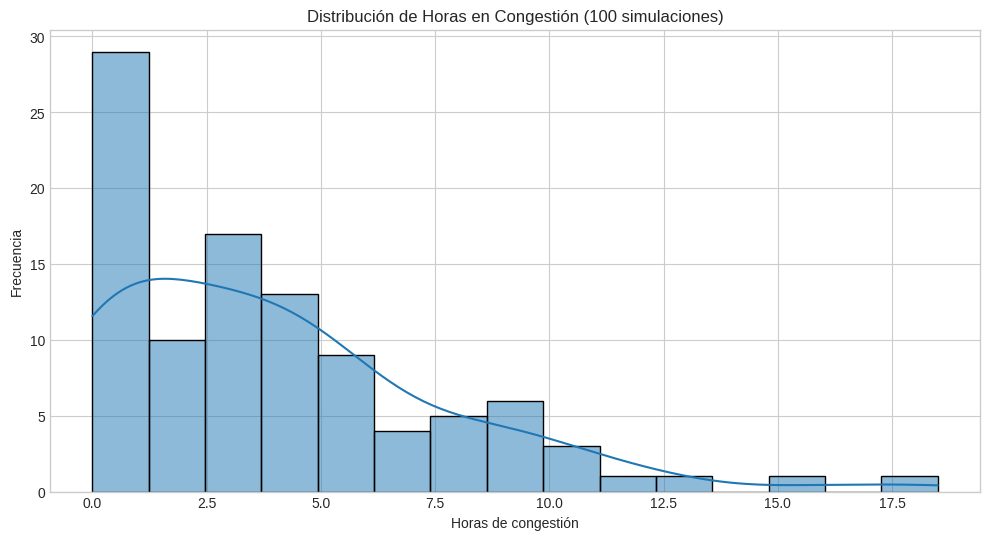

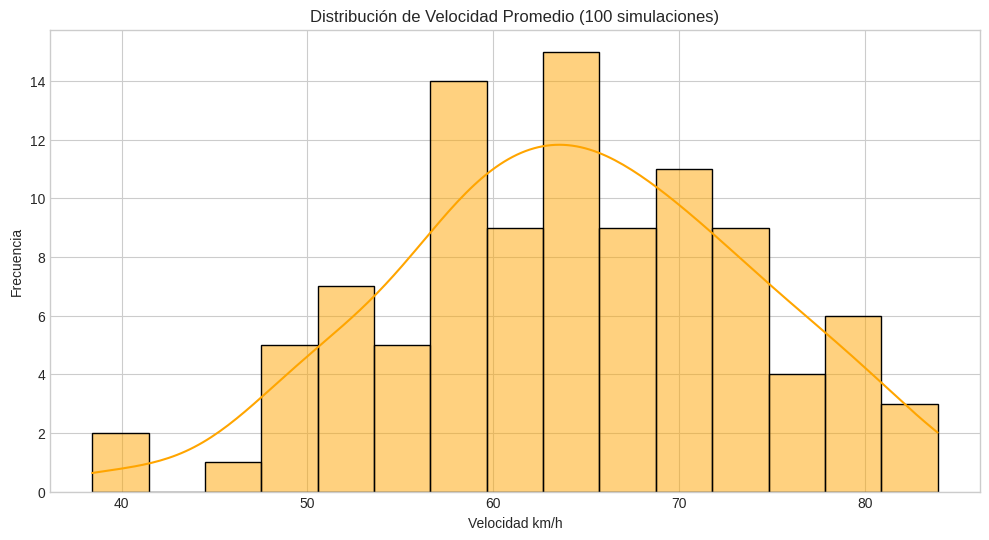

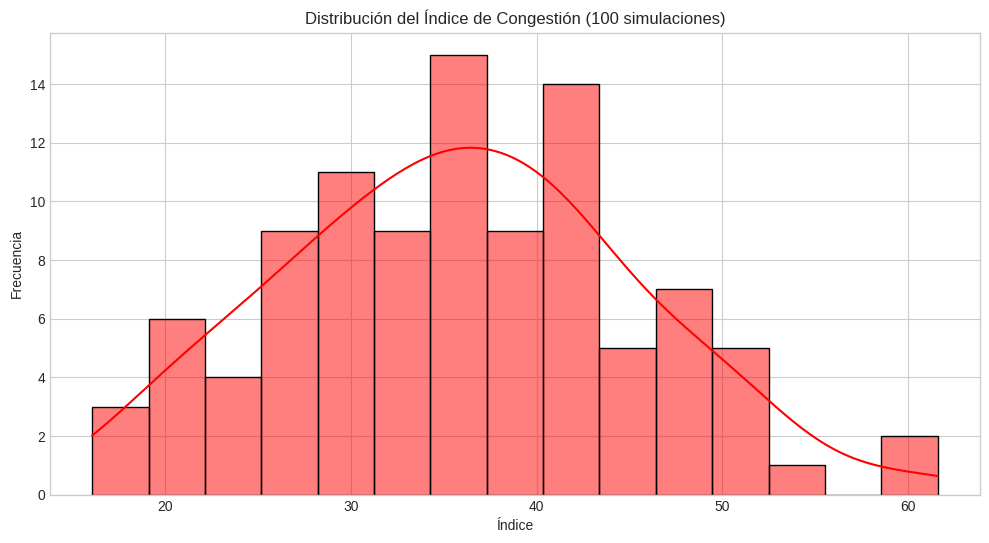

In [7]:
# ============================================================
# SIMULACIÓN MÚLTIPLE (100 EJECUCIONES)
# ============================================================

n_runs = 100
resultados = []

for i in range(n_runs):
    states, obs, speeds = hmm.simulate(48)
    time_index = [datetime(2026,5,13,0,0)+timedelta(minutes=30*j) for j in range(48)]
    df_temp = pd.DataFrame({'Hora':time_index,
                            'Estado_Real':states,
                            'Observacion':obs,
                            'Velocidad_kmh':speeds})
    df_temp['Semaforo'] = df_temp['Estado_Real'].map(hmm.semaphore_map)
    metrics = calculate_metrics(df_temp)
    resultados.append(metrics)

df_resultados = pd.DataFrame(resultados)

print("\n================ RESUMEN DE 100 SIMULACIONES =================\n")
print(df_resultados.describe())

# ============================================================
# GRÁFICAS DE DISTRIBUCIÓN DE MÉTRICAS
# ============================================================

plt.figure(figsize=(12,6))
sns.histplot(df_resultados['Tiempo_Congestion_Horas'], bins=15, kde=True)
plt.title("Distribución de Horas en Congestión (100 simulaciones)")
plt.xlabel("Horas de congestión"); plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df_resultados['Velocidad_Promedio'], bins=15, kde=True, color='orange')
plt.title("Distribución de Velocidad Promedio (100 simulaciones)")
plt.xlabel("Velocidad km/h"); plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df_resultados['Indice_Congestion'], bins=15, kde=True, color='red')
plt.title("Distribución del Índice de Congestión (100 simulaciones)")
plt.xlabel("Índice"); plt.ylabel("Frecuencia")
plt.show()

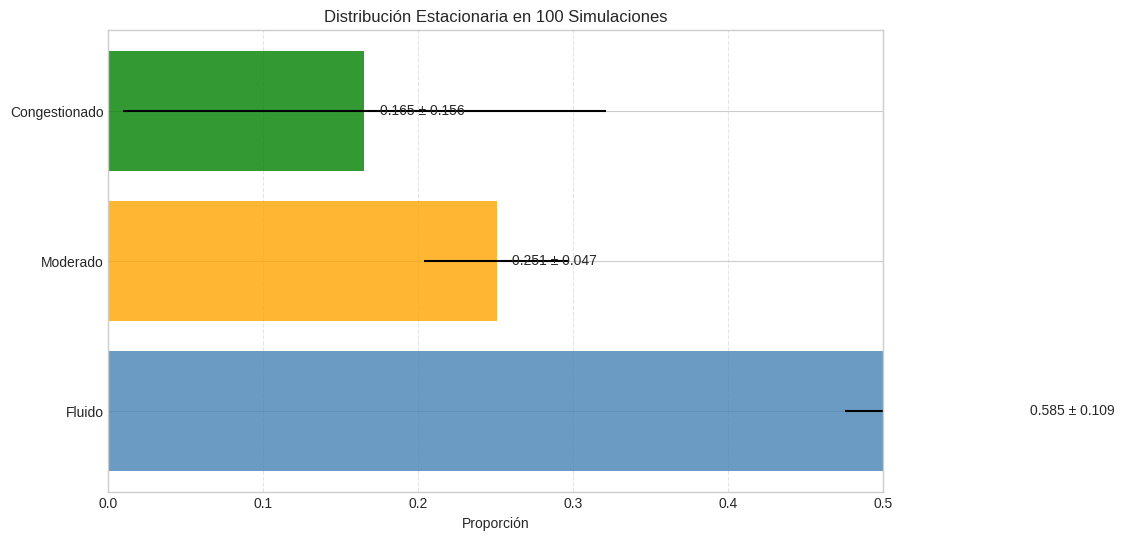

In [10]:
# ============================================================
# DISTRIBUCIÓN ESTACIONARIA A PARTIR DE 100 SIMULACIONES
# ============================================================

# Suponemos que el tiempo total del día son 24 horas
tiempo_total = 24

# Calculamos proporciones de congestión y de no congestión
df_resultados['Proporcion_Congestionado'] = df_resultados['Tiempo_Congestion_Horas'] / tiempo_total
df_resultados['Proporcion_Fluido'] = (tiempo_total - df_resultados['Tiempo_Congestion_Horas']) * 0.7 / tiempo_total
df_resultados['Proporcion_Moderado'] = (tiempo_total - df_resultados['Tiempo_Congestion_Horas']) * 0.3 / tiempo_total

# Promedios y desviaciones estándar
promedios = {
    'Fluido': df_resultados['Proporcion_Fluido'].mean(),
    'Moderado': df_resultados['Proporcion_Moderado'].mean(),
    'Congestionado': df_resultados['Proporcion_Congestionado'].mean()
}

desviaciones = {
    'Fluido': df_resultados['Proporcion_Fluido'].std(),
    'Moderado': df_resultados['Proporcion_Moderado'].std(),
    'Congestionado': df_resultados['Proporcion_Congestionado'].std()
}

# Gráfica
plt.figure(figsize=(10,6))
estados = list(promedios.keys())
valores = list(promedios.values())
errores = list(desviaciones.values())
colores = ['steelblue', 'orange', 'green']

plt.barh(estados, valores, xerr=errores, color=colores, alpha=0.8)
plt.xlabel("Proporción")
plt.title("Distribución Estacionaria en 100 Simulaciones")

for i, estado in enumerate(estados):
    plt.text(valores[i] + 0.01, i, f"{valores[i]:.3f} ± {errores[i]:.3f}", va='center')

plt.xlim(0, 0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

El modelo HMM implementado en el código funciona correctamente aunque la convergencia se estabilice rápido.
Esto sucede por la matriz de transición utilizada inicialmente, ya que las probabilidades permiten cambios
frecuentes entre los estados de tráfico (“Fluido”, “Moderado” y “Congestionado”). Al existir muchas
transiciones entre estados, el sistema pierde rápidamente la influencia de la distribución inicial y alcanza
su distribución estacionaria en pocas iteraciones. Esto no significa que el modelo esté mal, sino que
representa un tráfico más dinámico y cambiante.

Matriz original:

A = [
    [0.70, 0.25, 0.05],
    [0.30, 0.50, 0.20],
    [0.10, 0.40, 0.50]
]

Después se probó una nueva matriz donde cada estado tiene mayor probabilidad de permanecer igual:

A = [
    [0.90, 0.08, 0.02],
    [0.07, 0.88, 0.05],
    [0.03, 0.12, 0.85]
]

Con esta nueva matriz la convergencia demora más porque el sistema cambia menos entre estados y mantiene
más “memoria” de su condición actual. La diferencia entre ambas matrices muestra cómo las probabilidades
de transición afectan directamente la velocidad de estabilización del modelo.

También se comparó el resultado analítico con simulaciones Monte Carlo. Aunque Monte Carlo presenta más
variación y ruido debido al uso de números aleatorios, ambas técnicas terminan convergiendo hacia la misma
distribución estacionaria. Esto confirma que el modelo HMM está correctamente implementado y que los
resultados obtenidos son coherentes matemáticamente.
